<a href="https://colab.research.google.com/github/MKSILVER13/GRAFT/blob/KARMANYA_SINGH/GraphRag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Installing all necessary libraries
!pip install -q openai chromadb "sentence-transformers>=2.7.0" networkx "fastembed>=0.2.7"

print("--- All libraries installed ---")

# Import necessary modules
import os
import getpass
import json
import networkx as nx
import chromadb
from openai import OpenAI  # Import the OpenAI client
from sentence_transformers import SentenceTransformer, CrossEncoder

# --- Setup: Get OpenRouter API Key ---
# (This will create a pop-up to enter your key)
try:
    if 'GOOGLE_COLAB' in os.environ:
        from google.colab import userdata
        if "OPENROUTER_API_KEY" in userdata.keys():
            os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
            print("Found OPENROUTER_API_KEY in Colab secrets.")
        else:
            print("OPENROUTER_API_KEY not found in Colab secrets. Please enter it manually.")
            os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API Key: ")
    else:
        os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API Key: ")
except ImportError:
    os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API Key: ")


# --- Initialize OpenRouter Client ---
# We use the OpenAI client but point it to OpenRouter's API
openrouter_client = OpenAI(
    api_key=os.environ.get("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",  # This is the key change
    default_headers={
        "HTTP-Referer": "http://localhost/graphrag-demo", # Required by OpenRouter
        "X-Title": "GraphRAG Demo" # Optional
    }
)

# Initialize Embedding Model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize Reranker Model
reranker_model = CrossEncoder('BAAI/bge-reranker-base')

# --- Step 1: Create a Document Yourself ---
document_text = """
The discipline of Aethel-Gardening, first proposed by Dr. Aris Thorne, revolves around the cultivation of psycho-reactive flora. Unlike traditional botany, this practice requires the gardener to maintain specific mental states to influence plant growth and behavior.

The most basic plant used is Lumin-moss (LM-4). This moss lines the cultivation beds and acts as a passive bio-indicator. It responds directly to feelings of calm and serenity by producing a bright, silver-blue bioluminescence. This light is essential for the germination of other, more complex species.

A more advanced specimen is the Reso-bloom (RB-7). This flower responds not to broad emotions, but to focused, analytical thought. A successful cultivator can make the RB-7 align its crystalline petals into complex geometric patterns, a process used to 'solve' intricate conceptual problems.

The entire process is made possible by what Dr. Thorne termed the 'Symbiotic Resonance Field' (SRF). The SRF is a theoretical bio-etheric field that links the gardener's neural pathways with the flora's cellular structure. It's the medium through which intent is transmitted.

Initiating the Symbiotic Resonance Field is the most difficult step. It cannot be done by will alone. A 'Harmonic Tuning Fork' (HTF), a device calibrated to the gardener's unique brainwave signature, must be used. Striking the HTF and focusing on its hum is the standard method to establish the SRF.

The primary danger in Aethel-Gardening is the 'Dissonance Cascade.' If a gardener experiences sudden anxiety or fear, it can corrupt the SRF. This cascade instantly causes Lumin-moss (LM-4) to go dark and can lead to the rapid wilting and death of any active Reso-bloom (RB-7).
"""
print("--- 1. Document Created ---")

# --- Step 2: Vectorise it (Chunking) ---
chunks = document_text.split("\n\n")
doc_chunks = [{"id": i, "text": chunk} for i, chunk in enumerate(chunks)]
print(f"--- 2. Document split into {len(doc_chunks)} chunks ---")

chunk_texts = [chunk['text'] for chunk in doc_chunks]
chunk_embeddings = embedding_model.encode(chunk_texts, show_progress_bar=True)
print("--- 2b. Chunks vectorized ---")

# --- Step 3: Add it in database (Chroma) ---
client = chromadb.Client()
collection_name = "graph_rag_demo_openrouter"

if collection_name in [c.name for c in client.list_collections()]:
    client.delete_collection(name=collection_name)
collection = client.create_collection(name=collection_name)

collection.add(
    ids=[str(chunk['id']) for chunk in doc_chunks],
    documents=chunk_texts,
    embeddings=chunk_embeddings
)
print("--- 3. Chunks added to ChromaDB ---")

# --- Step 4 & 5: Create Nodes and Relation Edges (The Graph) ---
print("--- 4/5. Building graph... This may take a moment. ---")

# 4. Create Nodes
G = nx.Graph()
for chunk in doc_chunks:
    G.add_node(chunk['id'], text=chunk['text'])

# 5. Create Edges using LLM (OpenRouter)
chunk_texts_for_prompt = "\n\n".join([f"Chunk {c['id']}:\n{c['text']}" for c in doc_chunks])

edge_prompt = f"""
You are a graph builder. Based on the following document chunks, identify ALL connections between them.
A connection can be a direct reference, a cause-and-effect, a part-of relationship, or a conceptual link.

Respond ONLY with a JSON list of relationships in the format:
[
  {{ "source": <chunk_id_1>, "target": <chunk_id_2>, "relationship": "brief description of connection" }}
]

Do not include any other text or explanation. Your response must be *only* the JSON list.
Here are the chunks:
{chunk_texts_for_prompt}
"""

try:
    chat_completion = openrouter_client.chat.completions.create(
        messages=[{"role": "user", "content": edge_prompt}],
        model="openrouter/auto",  # Use the auto-router
        temperature=0
    )

    response_content = chat_completion.choices[0].message.content

    # Clean the response to find the JSON
    json_start = response_content.find('[')
    json_end = response_content.rfind(']') + 1

    if json_start == -1 or json_end == 0:
        raise ValueError("No JSON list found in LLM response")

    json_string = response_content[json_start:json_end]
    relations = json.loads(json_string)

    # Add edges to the graph
    for rel in relations:
        # Ensure 'source' and 'target' are integers
        src = int(rel['source'])
        tgt = int(rel['target'])
        if G.has_node(src) and G.has_node(tgt):
            G.add_edge(src, tgt, label=rel.get('relationship', 'related'))

    print(f"--- Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges ---")
    # print("Edges:", G.edges(data=True)) # Uncomment to see all edges

except Exception as e:
    print(f"Error processing LLM output for graph edges: {e}")
    print("LLM Output was:", chat_completion.choices[0].message.content if 'chat_completion' in locals() else "No response")


# --- Step 6: Do retrieval on database based on a query ---
def retrieve_initial_chunks(query, k=2):
    print(f"\n--- 6. Initial Retrieval (Vector Search for: '{query}') ---")
    query_embedding = embedding_model.encode([query])
    results = collection.query(
        query_embeddings=query_embedding.tolist(),
        n_results=k
    )
    initial_chunk_ids = [int(id_str) for id_str in results['ids'][0]]
    initial_texts = results['documents'][0]
    print(f"Found chunks: {initial_chunk_ids}")
    return initial_chunk_ids, initial_texts

# --- Step 7: Get other chunks from graph (Graph Traversal) ---
def get_graph_neighbors(node_ids):
    print(f"--- 7. Graph Traversal (Finding neighbors for: {node_ids}) ---")
    neighbor_ids = set()
    for node_id in node_ids:
        if G.has_node(node_id):
            neighbors = list(G.neighbors(node_id))
            neighbor_ids.update(neighbors)
            print(f"Neighbors for node {node_id}: {neighbors}")

    neighbor_ids = neighbor_ids - set(node_ids)
    neighbor_texts = [G.nodes[n_id]['text'] for n_id in neighbor_ids if G.has_node(n_id)]
    print(f"Found neighbor chunks: {list(neighbor_ids)}")
    return neighbor_texts

# --- Step 8: Rerank ---
def rerank_chunks(query, all_texts, top_n=3):
    print(f"--- 8. Reranking {len(all_texts)} total chunks ---")
    pairs = [[query, text] for text in all_texts]
    scores = reranker_model.predict(pairs, show_progress_bar=False)
    scored_texts = list(zip(all_texts, scores))
    scored_texts.sort(key=lambda x: x[1], reverse=True)
    reranked_texts = [text for text, score in scored_texts[:top_n]]
    print(f"Top {top_n} reranked chunks selected.")
    return reranked_texts

# --- Step 9 & 10: Merge query, retrieved data, and use LLM to get answer ---
def get_final_answer(query, context_texts):
    print("--- 9/10. Merging context and Generating Final Answer ---")
    context_str = "\n\n---\n\n".join(context_texts)

    final_prompt = f"""
You are an expert on Aethel-Gardening. Answer the user's query based ONLY on the provided context.
If the answer is not in the context, say "I do not have information about that based on the provided context."

Context:
---
{context_str}
---

Query:
{query}

Answer:
"""

    try:
        chat_completion = openrouter_client.chat.completions.create(
            messages=[{"role": "user", "content": final_prompt}],
            model="openrouter/auto",  # Use the auto-router
            temperature=0,
        )
        return chat_completion.choices[0].message.content
    except Exception as e:
        print(f"Error during final answer generation: {e}")
        return "Error generating final answer."

# --- Main Pipeline Execution Function ---
def run_graph_rag_pipeline(query):
    # Step 6: Initial Retrieval
    initial_ids, initial_texts = retrieve_initial_chunks(query, k=2)

    # Step 7: Graph Traversal
    neighbor_texts = get_graph_neighbors(initial_ids)

    # Combine and de-duplicate
    all_retrieved_texts = list(set(initial_texts + neighbor_texts))

    # Step 8: Rerank
    final_context_texts = rerank_chunks(query, all_retrieved_texts, top_n=3)

    # Step 9 & 10: Get Final Answer
    response = get_final_answer(query, final_context_texts)

    print("\n===================================")
    print(f"✅ Final Answer:\n{response}")
    print("===================================")
    print("\n--- Context Used for Answer: ---")
    print("\n---\n".join(final_context_texts))
    print("---------------------------------")


# --- EXECUTING THE PIPELINE ---
query_1 = "What happens if a gardener gets scared?"
run_graph_rag_pipeline(query_1)

# --- SECOND EXAMPLE ---
query_2 = "What is the purpose of the Reso-bloom RB-7?"
run_graph_rag_pipeline(query_2)

--- All libraries installed ---
Enter your OpenRouter API Key: ··········


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

--- 1. Document Created ---
--- 2. Document split into 6 chunks ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

--- 2b. Chunks vectorized ---
--- 3. Chunks added to ChromaDB ---
--- 4/5. Building graph... This may take a moment. ---
--- Graph created with 6 nodes and 11 edges ---

--- 6. Initial Retrieval (Vector Search for: 'What happens if a gardener gets scared?') ---
Found chunks: [5, 0]
--- 7. Graph Traversal (Finding neighbors for: [5, 0]) ---
Neighbors for node 5: [3, 1, 2]
Neighbors for node 0: [3, 4, 1, 2]
Found neighbor chunks: [1, 2, 3, 4]
--- 8. Reranking 6 total chunks ---
Top 3 reranked chunks selected.
--- 9/10. Merging context and Generating Final Answer ---

✅ Final Answer:
Sudden fear can trigger a Dissonance Cascade: it corrupts the SRF, instantly makes Lumin-moss (LM-4) go dark, and can cause any active Reso-bloom (RB-7) to rapidly wilt and die.

--- Context Used for Answer: ---
The primary danger in Aethel-Gardening is the 'Dissonance Cascade.' If a gardener experiences sudden anxiety or fear, it can corrupt the SRF. This cascade instantly causes Lumin-moss (LM-4) to go dark

In [3]:
# --- EXECUTING THE PIPELINE ---
query_1 = "What happens if a gardener gets scared?"
run_graph_rag_pipeline(query_1)

# --- SECOND EXAMPLE ---
query_2 = "What is the purpose of the Reso-bloom RB-7?"
run_graph_rag_pipeline(query_2)


--- 6. Initial Retrieval (Vector Search for: 'What happens if a gardener gets scared?') ---
Found chunks: [5, 0]
--- 7. Graph Traversal (Finding neighbors for: [5, 0]) ---
Neighbors for node 5: [3, 1, 2]
Neighbors for node 0: [3, 4, 1, 2]
Found neighbor chunks: [1, 2, 3, 4]
--- 8. Reranking 6 total chunks ---
Top 3 reranked chunks selected.
--- 9/10. Merging context and Generating Final Answer ---

✅ Final Answer:
It can trigger a Dissonance Cascade: the fear corrupts the SRF, Lumin-moss (LM-4) goes dark immediately, and any active Reso-bloom (RB-7) can rapidly wilt and die.

--- Context Used for Answer: ---
The primary danger in Aethel-Gardening is the 'Dissonance Cascade.' If a gardener experiences sudden anxiety or fear, it can corrupt the SRF. This cascade instantly causes Lumin-moss (LM-4) to go dark and can lead to the rapid wilting and death of any active Reso-bloom (RB-7).

---
The entire process is made possible by what Dr. Thorne termed the 'Symbiotic Resonance Field' (SRF).

--- 5b. Building Visualization Knowledge Graph (knowledge_graph)... ---
--- Visualization Graph (knowledge_graph) created with 33 nodes. ---
Entities found: 27


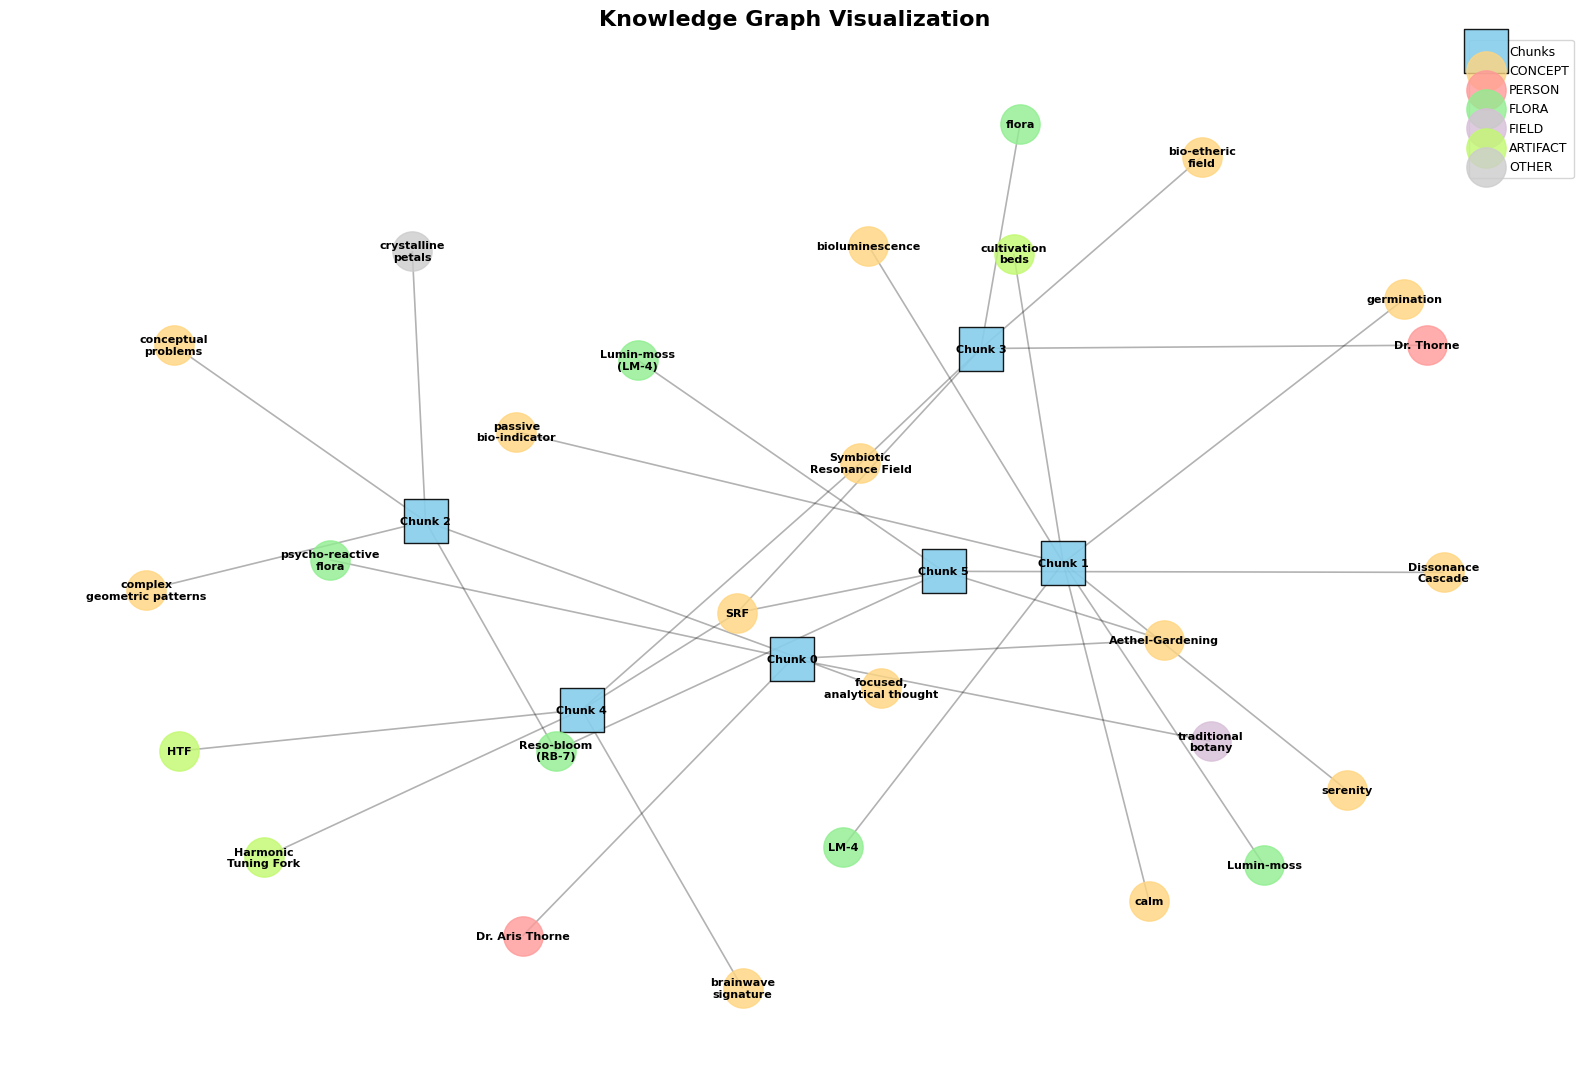

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import json # Make sure json is imported in this cell too

# --- Step 5b: Create Knowledge Graph for Visualization ---

def create_knowledge_graph(doc_chunks_list):
    """
    Creates a detailed knowledge graph with 'chunk' and 'entity' nodes.
    This function uses the 'openrouter_client' defined in the previous cell.
    """
    print("--- 5b. Building Visualization Knowledge Graph (knowledge_graph)... ---")
    knowledge_graph = nx.Graph()
    all_entities = set()
    chunk_entities_map = {} # To store which entities are in which chunk

    # 1. Add all chunk nodes
    for chunk in doc_chunks_list:
        knowledge_graph.add_node(
            chunk['id'],
            type='chunk',
            text=chunk['text']
        )

    # 2. Define NER (Named Entity Recognition) prompt
    ner_prompt_template = """
    You are an expert entity extractor. Extract key entities from the following text.
    Classify each entity into one of these labels:
    - CONCEPT (for abstract ideas, e.g., 'Aethel-Gardening', 'Dissonance Cascade')
    - ARTIFACT (for specific tools or items, e.g., 'Harmonic Tuning Fork')
    - FLORA (for plants, e.g., 'Lumin-moss', 'Reso-bloom')
    - PERSON (for people, e.g., 'Dr. Aris Thorne')
    - FIELD (for fields of study, e.g., 'traditional botany')
    - OTHER (for anything else important)

    Respond ONLY with a JSON object in the format:
    {{
      "entities": [
        {{"text": "entity name", "label": "ENTITY_LABEL"}}
      ]
    }}

    Text to analyze:
    {text}
    """

    # 3. Process each chunk to find entities
    for chunk in doc_chunks_list:
        chunk_id = chunk['id']
        chunk_text = chunk['text']

        try:
            prompt = ner_prompt_template.format(text=chunk_text)
            # Uses 'openrouter_client' from the previous cell
            chat_completion = openrouter_client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model="openrouter/auto",
                temperature=0,
                response_format={"type": "json_object"}
            )
            response_data = json.loads(chat_completion.choices[0].message.content)
            entities = response_data.get('entities', [])

            chunk_entities_map[chunk_id] = []

            for entity in entities:
                entity_text = entity['text']
                entity_label = entity['label']

                # Add entity node (duplicates are automatically handled)
                knowledge_graph.add_node(
                    entity_text,
                    type='entity',
                    text=entity_text,
                    label=entity_label
                )

                # Add to sets for tracking
                all_entities.add(entity_text)
                chunk_entities_map[chunk_id].append(entity_text)

                # Add edge from chunk to entity
                knowledge_graph.add_edge(chunk_id, entity_text, label='contains')

        except Exception as e:
            print(f"Error extracting entities from chunk {chunk_id}: {e}")

    print(f"--- Visualization Graph (knowledge_graph) created with {knowledge_graph.number_of_nodes()} nodes. ---")
    return knowledge_graph, chunk_entities_map, all_entities


# --- Step 5c: Visualization Function ---

def visualize_graph(G: nx.Graph, max_nodes: int = 40):
    """
    Visualize the knowledge graph with color-coded node types and entity labels.
    """
    # Sample nodes if graph is too large
    if G.number_of_nodes() > max_nodes:
        # Prioritize showing a mix of chunks and entities
        chunk_nodes_all = [n for n, data in G.nodes(data=True) if data.get('type') == 'chunk']
        entity_nodes_all = [n for n, data in G.nodes(data=True) if data.get('type') == 'entity']

        # Take a few chunks and their connected entities
        nodes_to_display = set()
        for chunk_node in chunk_nodes_all[:5]: # Take first 5 chunks
            nodes_to_display.add(chunk_node)
            neighbors = list(G.neighbors(chunk_node))
            nodes_to_display.update(neighbors[:5]) # Add up to 5 entities per chunk
            if len(nodes_to_display) > max_nodes:
                break

        nodes_to_display = list(nodes_to_display)[:max_nodes]
        G_display = G.subgraph(nodes_to_display)
    else:
        G_display = G

    plt.figure(figsize=(16, 11))

    # Separate node types
    chunk_nodes = [n for n in G_display.nodes() if G_display.nodes[n].get('type') == 'chunk']
    entity_nodes = [n for n in G_display.nodes() if G_display.nodes[n].get('type') == 'entity']

    # Group entity nodes by label (CONCEPT, FLORA, etc.)
    entity_types = {}
    for node in entity_nodes:
        label = G_display.nodes[node].get('label', 'OTHER')
        entity_types.setdefault(label, []).append(node)

    # Layout for visualization
    pos = nx.spring_layout(G_display, k=0.8, iterations=50, seed=42)

    # Draw chunk nodes
    nx.draw_networkx_nodes(
        G_display, pos, nodelist=chunk_nodes,
        node_color='skyblue', node_size=1000,
        label='Chunks', alpha=0.9, edgecolors='black', node_shape='s' # square
    )

    # Draw entity nodes by category with distinct colors
    color_map = {
        'CONCEPT': '#FFD580', # orange
        'ARTIFACT': '#C2F970', # green
        'FLORA': '#90EE90', # lightgreen
        'PERSON': '#FF9999', # pink
        'FIELD': '#D8BFD8', # thistle
        'OTHER': '#CCCCCC' # grey
    }

    # Draw entity nodes
    for label, nodes in entity_types.items():
        nx.draw_networkx_nodes(
            G_display, pos, nodelist=nodes,
            node_color=color_map.get(label, '#CCCCCC'),
            node_size=800, label=label, alpha=0.8
        )

    # Draw edges
    nx.draw_networkx_edges(G_display, pos, alpha=0.3, width=1.2)

    # Create readable labels
    labels = {}
    for n, data in G_display.nodes(data=True):
        if data['type'] == 'chunk':
            labels[n] = f"Chunk {n}"  # show chunk IDs
        else:
            text = data.get('text', n)
            # Simple text wrapping for labels
            if len(text) > 15:
                parts = text.split(' ')
                if len(parts) > 1:
                    labels[n] = f"{parts[0]}\n{' '.join(parts[1:])}"
                else:
                    labels[n] = text
            else:
                labels[n] = text

    nx.draw_networkx_labels(G_display, pos, labels, font_size=8, font_weight='bold')

    plt.title("Knowledge Graph Visualization", fontsize=16, fontweight='bold')
    plt.legend(scatterpoints=1, fontsize=9, loc='upper right')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Run the Visualization ---
# This uses 'doc_chunks' from the previous cell
knowledge_graph, chunk_entities, all_entities = create_knowledge_graph(doc_chunks)
print(f"Entities found: {len(all_entities)}")

visualize_graph(knowledge_graph, max_nodes=40)